## The problem I'm trying to solve
Predict road accident severity - fatal / serious / slight - from conditions at the time of the accident.

The core challenge is class imbalance:
1. Fatal: 1.5%
2. Serious: 22%
3. Slight: 76.5%

To predict and evaluate this I will use F1-score.

1. Split data into train and test
2. Logistic regression baseline
3. XGBoost
4. Compare both

In [5]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [7]:
df = pd.read_csv("../data/processed/accidents_features.csv")

In [8]:
X = df.drop(columns=["collision_severity"])
y = df["collision_severity"]

In [9]:
print("features shape:", X.shape)
print("target shape:", y.shape)
print()
print("Class distribution:")
print(y.value_counts().sort_index())

features shape: (106004, 21)
target shape: (106004,)

Class distribution:
collision_severity
1     1602
2    23333
3    81069
Name: count, dtype: int64


In [10]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print()
print("Train class distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)
print()
print("Test class distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

Training set: (84803, 21)
Test set: (21201, 21)

Train class distribution:
collision_severity
1     1.511739
2    22.011014
3    76.477247
Name: proportion, dtype: float64

Test class distribution:
collision_severity
1     1.509363
2    22.013113
3    76.477525
Name: proportion, dtype: float64


In [11]:
print(y_train.value_counts().sort_index())

collision_severity
1     1282
2    18666
3    64855
Name: count, dtype: int64


## Logistic Regression
Logistic regression is simple and fast. It assumes the linear relationships between features and outcomes. I am using it as a reference point.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [14]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [15]:
y_pred = lr.predict(X_test_scaled)

In [16]:
print("Logisitic Regression Baseline:")
print(classification_report(y_test, y_pred, target_names=["Fatal", "Serious", "Slight"]))

Logisitic Regression Baseline:
              precision    recall  f1-score   support

       Fatal       1.00      1.00      1.00       320
     Serious       1.00      1.00      1.00      4667
      Slight       1.00      1.00      1.00     16214

    accuracy                           1.00     21201
   macro avg       1.00      1.00      1.00     21201
weighted avg       1.00      1.00      1.00     21201



In [17]:
print(X.columns.tolist())

['road_type', 'speed_limit', 'urban_or_rural_area', 'junction_detail', 'junction_control', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'carriageway_hazards', 'number_of_vehicles', 'number_of_casualties', 'vehicle_type_mode', 'any_skidding', 'avg_vehicle_age', 'worst_casualty_severity', 'any_pedestrian', 'avg_casualty_age', 'time_sin', 'time_cos', 'day_sin', 'day_cos']


## Data leakage
The model is getting 100 accuracy, this means something is wrong.
worst_casualty_severity, any_pedestrian, avg_casualty_age come from the casualties table. They describe outcomes after the accident, not conditions that existed before it.

So using them to predict collision severity means using the answer to predict the answer.

In [18]:
# remove the leaking columns

leaking_cols = ["worst_casualty_severity", "any_pedestrian", "avg_casualty_age"]

X = df.drop(columns=["collision_severity"] + leaking_cols)
y = df["collision_severity"]

print(X.shape)
print(X.columns.tolist())

(106004, 18)
['road_type', 'speed_limit', 'urban_or_rural_area', 'junction_detail', 'junction_control', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'carriageway_hazards', 'number_of_vehicles', 'number_of_casualties', 'vehicle_type_mode', 'any_skidding', 'avg_vehicle_age', 'time_sin', 'time_cos', 'day_sin', 'day_cos']


In [19]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print()
print("Train class distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)
print()
print("Test class distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

Training set: (84803, 18)
Test set: (21201, 18)

Train class distribution:
collision_severity
1     1.511739
2    22.011014
3    76.477247
Name: proportion, dtype: float64

Test class distribution:
collision_severity
1     1.509363
2    22.013113
3    76.477525
Name: proportion, dtype: float64


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [21]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [22]:
y_pred = lr.predict(X_test_scaled)

In [23]:
print("Logisitic Regression Baseline:")
print(classification_report(y_test, y_pred, target_names=["Fatal", "Serious", "Slight"]))

Logisitic Regression Baseline:
              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00       320
     Serious       0.50      0.01      0.01      4667
      Slight       0.77      1.00      0.87     16214

    accuracy                           0.77     21201
   macro avg       0.42      0.34      0.29     21201
weighted avg       0.70      0.77      0.67     21201



D:\Github\AccidentIQ\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Github\AccidentIQ\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Github\AccidentIQ\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 📝 key observation
- Fatal f1-score: 0.00 (the model is ignoring Fatal because it only has 1282 Fatal examples vs 64,855 Slight examples in training)
- Serious F1-score: 0.01
- Slight F1-score: 0.87 - model is inclined towards slight due to imbalance problem.
- Accuracy: 0.77 

These results confirm that there is class imbalance. 

## XGBoost  
It is an optimized gradient boosting algorithm that combines multiple weak models into stronger and high performance model. It uses decision trees as base learner, and features parallel processing for faster training on large datasets.

- Here, logistic regression ignored fatal completely because model learned to minimize overall error and Slight dominates here.

In [24]:
!pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from xgboost import XGBClassifier

In [27]:
# calculate scale_pos_weight for Fatal class

fatal_count = (y_train == 1).sum()
nonfatal_count = (y_train != 1).sum()

scale = nonfatal_count / fatal_count
print(f"Fatal examples: {fatal_count}")
print(f"Non-fatal examples: {nonfatal_count}")
print(f"scale_pos_weight: {scale:.1f}") 

Fatal examples: 1282
Non-fatal examples: 83521
scale_pos_weight: 65.1


### Note: scale_pos_weight: 65.1

In [28]:
from sklearn.metrics import classification_report

In [31]:
xgb = XGBClassifier(n_estimators=100, scale_pos_weight=65, 
                    random_state=42, eval_metric="mlogloss", 
                    verbosity=0
                   )

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got [1 2 3]

In [32]:
y_train_xgb = y_train - 1
y_test_xgb  = y_test - 1

print("Original labels:", y_train.unique().tolist())
print("Adjusted labels:", y_train_xgb.unique().tolist())
print("Earlier Fatal, Seriour, Slight were 1,2,3.")
print(" 0 = Fatal")
print(" 1 = Serious")
print(" 2 = Slight")

Original labels: [3, 1, 2]
Adjusted labels: [2, 0, 1]
Earlier Fatal, Seriour, Slight were 1,2,3.
 0 = Fatal
 1 = Serious
 2 = Slight


In [33]:
xgb = XGBClassifier(n_estimators=100, scale_pos_weight=65, random_state=42, 
                    eval_metric="mlogloss", verbosity=0 )

xgb.fit(X_train, y_train_xgb)
y_pred_xgb = xgb.predict(X_test)

print("XGBOOST RESULTS")
print(classification_report(y_test_xgb, y_pred_xgb,
      target_names=["Fatal", "Serious", "Slight"]))

XGBOOST RESULTS
              precision    recall  f1-score   support

       Fatal       0.24      0.02      0.03       320
     Serious       0.50      0.11      0.18      4667
      Slight       0.78      0.97      0.87     16214

    accuracy                           0.77     21201
   macro avg       0.51      0.37      0.36     21201
weighted avg       0.71      0.77      0.70     21201



In [35]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_xgb
)

print("Sample weight for each class:")
print(f"Fatal: {sample_weights[y_train_xgb == 0][0]:.1f}")
print(f"Serious: {sample_weights[y_train_xgb == 1][0]:.1f}")
print(f"Slight: {sample_weights[y_train_xgb == 2][0]:.1f}")

# retrain with sample weights
xgb2 = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="mlogloss",
    verbosity=0
)

xgb2.fit(X_train, y_train_xgb, sample_weight=sample_weights)
y_pred_xgb2 = xgb2.predict(X_test)

print("\nXGBOOST WITH SAMPLE WEIGHTS")
print(classification_report(y_test_xgb, y_pred_xgb2,
      target_names=["Fatal", "Serious", "Slight"]))

Sample weight for each class:
Fatal: 22.0
Serious: 1.5
Slight: 0.4

XGBOOST WITH SAMPLE WEIGHTS
              precision    recall  f1-score   support

       Fatal       0.06      0.38      0.10       320
     Serious       0.31      0.48      0.38      4667
      Slight       0.85      0.62      0.72     16214

    accuracy                           0.58     21201
   macro avg       0.41      0.49      0.40     21201
weighted avg       0.72      0.58      0.63     21201



In [36]:
xgb3 = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42,
                     eval_metric="mlogloss", verbosity=0)
xgb3.fit(X_train, y_train_xgb, sample_weight=sample_weights)
y_pred_xgb3 = xgb3.predict(X_test)

print("XGBoost 30 TREES")
print(classification_report(y_test_xgb, y_pred_xgb3, target_names=["Fatal","Serious","Slight"]))

XGBoost 30 TREES
              precision    recall  f1-score   support

       Fatal       0.06      0.39      0.10       320
     Serious       0.31      0.47      0.38      4667
      Slight       0.85      0.62      0.72     16214

    accuracy                           0.58     21201
   macro avg       0.41      0.50      0.40     21201
weighted avg       0.72      0.58      0.63     21201



### 📝Note
1. We tried 3 class prediction. Fatal F1 plateaued at 0.10 whatever we changed - more trees, different weights or even threshold tuning.
2. Fatal and Serious look identical in our data. Our 18 features is not able to tell them apart because the difference between Fatal and Serious is something that can be called as the angle of impact - like how quickly the ambulance arrived or whether someone wore a seatbelt or not. None of those are in our dataset.
3. A traffic authority or any road safety officer does not have to know the difference between Serious and Slight. They need to know one thing that is the accident going to be Fatal. That is Binary, Clear and Answerable.
4. When we collapse Serious and Slight into one Non-Fatal class, we give model a cleaner path to learn from. Fatal vs Non-Fatal. This way the task is more tractable and result is more honest and actionable.


In [38]:
y_binary = (y == 1).astype(int)

print("Binary class distribution:")
print(f" Fatal(1): {y_binary.sum():,} ({y_binary.mean()*100:.1f}%)")
print(f" Non-Fatal(0): {(y_binary==0).sum():,} ({(y_binary==0).mean()*100:.1f}%)")

Binary class distribution:
 Fatal(1): 1,602 (1.5%)
 Non-Fatal(0): 104,402 (98.5%)


In [59]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_bin, y_bin)):

    X_fold_train = X_bin.iloc[train_idx]
    X_fold_val = X_bin.iloc[val_idx]
    y_fold_train = y_bin.iloc[train_idx]
    y_fold_val = y_bin.iloc[val_idx]

    model = XGBClassifier( n_estimators=200, scale_pos_weight=65,
                           max_depth=6, learning_rate=0.1, random_state=42,
                           verbosity=0
                         )

    model.fit(X_fold_train, y_fold_train)

    y_proba = model.predict_proba(X_fold_val)[:, 1]
    auc = roc_auc_score(y_fold_val, y_proba)
    auc_scores.append(auc)

    print(f"Fold {fold+1}: AUC = {auc:.3f}")

print(f"\nMean AUC : {np.mean(auc_scores):.3f}")
print(f"Std  AUC : {np.std(auc_scores):.3f}")

Fold 1: AUC = 0.788
Fold 2: AUC = 0.777
Fold 3: AUC = 0.780
Fold 4: AUC = 0.771
Fold 5: AUC = 0.787

Mean AUC : 0.781
Std  AUC : 0.007


In [60]:
print(df.columns.tolist())

['collision_severity', 'road_type', 'speed_limit', 'urban_or_rural_area', 'junction_detail', 'junction_control', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'carriageway_hazards', 'number_of_vehicles', 'number_of_casualties', 'vehicle_type_mode', 'any_skidding', 'avg_vehicle_age', 'worst_casualty_severity', 'any_pedestrian', 'avg_casualty_age', 'time_sin', 'time_cos', 'day_sin', 'day_cos']


In [61]:
leaking_cols = [
    "worst_casualty_severity",
    "any_pedestrian", 
    "avg_casualty_age",
    "collision_severity"  # this is the target, not a feature
]

X_bin = df.drop(columns=leaking_cols)
y_bin = (df["collision_severity"] == 1).astype(int)

print("Clean features:", X_bin.shape)
print(X_bin.columns.tolist())

Clean features: (106004, 18)
['road_type', 'speed_limit', 'urban_or_rural_area', 'junction_detail', 'junction_control', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'carriageway_hazards', 'number_of_vehicles', 'number_of_casualties', 'vehicle_type_mode', 'any_skidding', 'avg_vehicle_age', 'time_sin', 'time_cos', 'day_sin', 'day_cos']


In [62]:
df_clean_final = df.drop(columns=[
    "worst_casualty_severity",
    "any_pedestrian",
    "avg_casualty_age"
])

df_clean_final.to_csv("../data/processed/accidents_features.csv", index=False)
print("Clean file saved. Leaking columns removed permanently.")

Clean file saved. Leaking columns removed permanently.


In [63]:
from sklearn.model_selection import train_test_split
import joblib
import os

# final train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

# train final model on full training set
final_model = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_weight,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="auc",
    verbosity=0
)

final_model.fit(X_train, y_train)

# save model
os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/xgb_fatal_predictor.pkl")

print("Model saved to models/xgb_fatal_predictor.pkl")
print()

# final evaluation on held-out test set
from sklearn.metrics import classification_report, roc_auc_score

y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("FINAL MODEL with TEST SET EVALUATION")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred,
      target_names=["Non-Fatal", "Fatal"]))

Model saved to models/xgb_fatal_predictor.pkl

FINAL MODEL with TEST SET EVALUATION
AUC-ROC: 0.800

              precision    recall  f1-score   support

   Non-Fatal       0.99      0.86      0.92     20881
       Fatal       0.06      0.53      0.10       320

    accuracy                           0.86     21201
   macro avg       0.52      0.70      0.51     21201
weighted avg       0.98      0.86      0.91     21201



### Results
- AUC-ROC: 0.800
- Fatal Recall: 0.53
- Fatal Precision: 0.06
- Non-Fatal Precision: 0.99

For Fatal Class: Recall = 0.53 (model catches 53% of real fatal accidents), 
Precision = 0.06 (6 out of 100 fatal predictions are correct)

Improvement over random baseline: AUC 0.500 -> 0.800 (+60%)

In [65]:
!pip install shap

  Using cached shap-0.51.0-cp311-cp311-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.1-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.47.0-cp311-cp311-win_amd64.whl.metadata (4.9 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.51.0-cp311-cp311-win_amd64.whl (554 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.47.0-cp311-cp311-win_amd64.whl (38.1 MB)
Using cached numba-0.65.1-cp311-cp311-win_amd64.whl (2.7 MB)



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
import shap

In [67]:
explainer = shap.TreeExplainer(final_model)

In [68]:
shap_values = explainer.shap_values(X_test)

In [69]:
print(shap_values.shape)
print(X_test.shape)

(21201, 18)
(21201, 18)


In [71]:
import matplotlib.pyplot as plt
import os

In [72]:
# calculate average SHAP impact per feature

mean_shap_values = np.abs(shap_values).mean(axis=0)

In [73]:
# pair each feature name with its SHAP score

feature_names = X_test.columns.tolist()

In [74]:
shap_importance = pd.DataFrame({
    "feature"   : feature_names,
    "importance": mean_shap_values
})

In [75]:
# sort so most important feature is at top

shap_importance = shap_importance.sort_values(
    "importance", ascending=True
)

In [76]:
# print the ranking

print("Feature importance ranking:")
print(shap_importance.to_string(index=False))

Feature importance ranking:
                feature  importance
        junction_detail    0.070518
road_surface_conditions    0.074287
                day_sin    0.080008
    carriageway_hazards    0.103861
       light_conditions    0.119981
                day_cos    0.121634
     weather_conditions    0.129931
       junction_control    0.168900
   number_of_casualties    0.182206
        avg_vehicle_age    0.204273
              road_type    0.206978
    urban_or_rural_area    0.255984
      vehicle_type_mode    0.258771
               time_sin    0.277307
               time_cos    0.290128
           any_skidding    0.436379
     number_of_vehicles    0.449962
            speed_limit    0.530034


In [77]:
os.makedirs("../reports/figures", exist_ok=True)

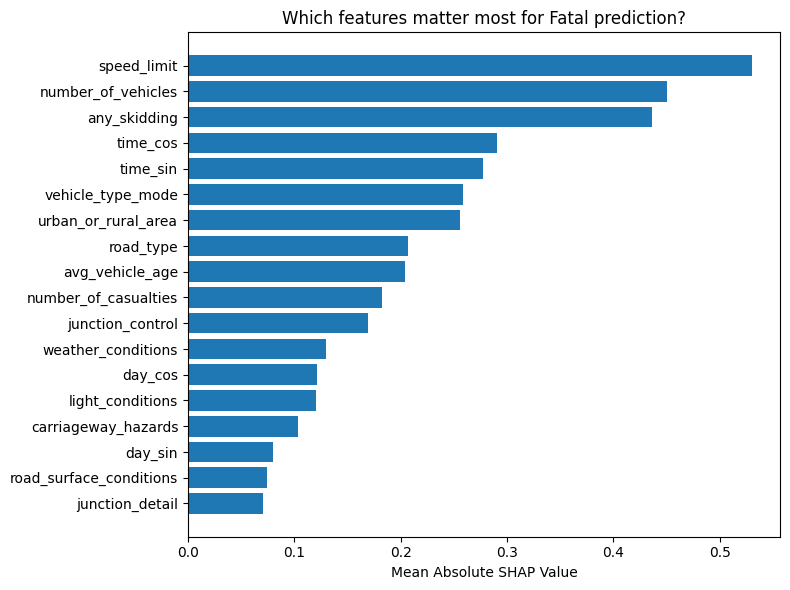

Plot saved.


In [78]:
plt.figure(figsize=(8, 6))
plt.barh(shap_importance["feature"], shap_importance["importance"])
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Which features matter most for Fatal prediction?")
plt.tight_layout()
plt.savefig("../reports/figures/shap_global.png", dpi=150)
plt.show()

print("Plot saved.")

In [80]:
fatal_indices = X_test[y_test == 1].index.tolist()
print(f"Fatal accidents in test set: {len(fatal_indices)}")

# take the first one
example_idx = fatal_indices[0]
example = X_test.loc[[example_idx]]

print("\nAccident conditions:")
for col in example.columns:
    print(f"{col}: {example[col].values[0]}")

prob = final_model.predict_proba(example)[0][1]
print(f"\nModel Fatal probability: {prob:.3f}")
print(f"Actual label: Fatal" if y_test.loc[example_idx] == 1 else "Actual label: Non-Fatal")

Fatal accidents in test set: 320

Accident conditions:
road_type: 7
speed_limit: 70
urban_or_rural_area: 2
junction_detail: 0
junction_control: -1
light_conditions: 4
weather_conditions: 1
road_surface_conditions: 2
carriageway_hazards: 0
number_of_vehicles: 1
number_of_casualties: 1
vehicle_type_mode: 21
any_skidding: 0
avg_vehicle_age: 4.0
time_sin: 0.3502073812594674
time_cos: 0.9366721892483976
day_sin: -0.7818314824680299
day_cos: 0.6234898018587334

Model Fatal probability: 0.439
Actual label: Fatal


In [81]:
# calculate SHAP values for this one accident

example_shap = explainer.shap_values(example)

# pair feature names with their SHAP values

local_explanation = pd.DataFrame({
    "feature"   : X_test.columns.tolist(),
    "shap_value": example_shap[0]
})

# sort by absolute impact

local_explanation = local_explanation.sort_values(
    "shap_value", ascending=False
)

print("Local SHAP")
print()
print("Features pushing TOWARD Fatal (positive values):")
pushing_toward = local_explanation[local_explanation["shap_value"] > 0]
print(pushing_toward.to_string(index=False))

print()
print("Features pushing AWAY from Fatal (negative values):")
pushing_away = local_explanation[local_explanation["shap_value"] < 0]
print(pushing_away.to_string(index=False))

Local SHAP

Features pushing TOWARD Fatal (positive values):
                feature  shap_value
     number_of_vehicles    0.542418
            speed_limit    0.477825
      vehicle_type_mode    0.330558
       junction_control    0.219906
           any_skidding    0.164170
               time_sin    0.120758
road_surface_conditions    0.084204
     weather_conditions    0.032603
    carriageway_hazards    0.016431
       light_conditions    0.004267

Features pushing AWAY from Fatal (negative values):
             feature  shap_value
 urban_or_rural_area   -0.012484
             day_cos   -0.017424
     junction_detail   -0.061795
             day_sin   -0.107542
     avg_vehicle_age   -0.111619
            time_cos   -0.140080
number_of_casualties   -0.160443
           road_type   -1.620692


### Note
- Global SHAP confirmed my EDA findings. Speed limit was the most important feature. The model learned this pattern independently from the data.
- Local SHAP let me explain individual predictions. There is uncertainty in this. Model Fatal probability: 0.439
Actual label: Fatal